In [1]:
# ============================================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================================

import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import deep_sdf.workspace as ws
import networks.sdf_vae as vae
import json
import time
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, SpectralEmbedding
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Set up paths for supervised model
experiment_directory = "examples/hippocampus_MS"  # Changed from hippocampus_healthy

# Load specs
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]

# Model parameters
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

print("="*60)
print("AGE-SUPERVISED HIPPOCAMPUS LATENT ANALYSIS")
print("="*60)
print(f"Latent size: {latent_size}")
print(f"Supervised dimension: z[1] (age)")

AGE-SUPERVISED HIPPOCAMPUS LATENT ANALYSIS
Latent size: 16
Supervised dimension: z[1] (age)


In [2]:
# ============================================================================
# CELL 2: MODEL LOADING AND LATENT EXTRACTION
# ============================================================================

def load_supervised_model_and_extract_latents():
    """Load supervised model and extract latent variables for all training data"""
    
    # Load supervised model from hippocampus_MS
    decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
    
    model_file = os.path.join(experiment_directory, "ModelParameters", "2000.pth")
    if os.path.exists(model_file):
        print(f"Loading supervised model from: {model_file}")
        saved_model_state = torch.load(model_file)
        decoder.load_state_dict(saved_model_state["model_state_dict"])
        decoder.eval()
        print("Supervised model loaded successfully!")
    else:
        raise FileNotFoundError(f"Model file not found: {model_file}")
    
    # Load training data
    with open(train_split_file, "r") as f:
        train_split = json.load(f)
    
    # Get training filenames
    import deep_sdf.data as data
    eval_train_filenames = data.get_instance_filenames(data_source, train_split)
    
    # Load labels
    labels_path = os.path.join(data_source, "labels.pt")
    all_labels = torch.load(labels_path)
    
    # Extract latents for each training sample
    all_latents = []
    all_ages = []
    all_diseases = []
    filenames = []
    
    print(f"Extracting latents from {len(eval_train_filenames)} training samples...")
    
    with torch.no_grad():
        for i, train_fname in enumerate(eval_train_filenames):
            if i % 50 == 0:
                print(f"Processing {i}/{len(eval_train_filenames)}")
                
            save_name = os.path.basename(train_fname).split(".npz")[0]
            mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
            
            # Get surface points
            surface_points = data.get_surface_points(mesh_path)
            surface_points = torch.from_numpy(surface_points).unsqueeze(0).cuda()
            
            # Extract latent using encoder
            if kl_div_loss:
                mu, logvar = decoder.encoder(surface_points)
                latent = mu
            else:
                latent = decoder.encoder(surface_points)
            
            all_latents.append(latent.cpu().numpy().squeeze())
            
            # Get labels
            if save_name in all_labels:
                label = all_labels[save_name]
                all_ages.append(float(label[0].item()))
                all_diseases.append(int(label[1].item()))
            else:
                print(f"Warning: No label found for {save_name}")
                all_ages.append(0.0)
                all_diseases.append(0)
            
            filenames.append(save_name)
    
    latents_array = np.stack(all_latents, axis=0)
    print(f"Extracted latents shape: {latents_array.shape}")
    
    return {
        'latents': latents_array,
        'ages': np.array(all_ages),
        'diseases': np.array(all_diseases),
        'filenames': filenames,
        'decoder': decoder
    }

# Extract latents from supervised model
print("="*60)
print("EXTRACTING LATENTS FROM SUPERVISED MODEL")
print("="*60)

supervised_data = load_supervised_model_and_extract_latents()

# Save the extracted latents
save_dir = os.path.join(experiment_directory, "supervised_age_analysis")
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "supervised_latents.npy"), supervised_data['latents'])
np.save(os.path.join(save_dir, "ages.npy"), supervised_data['ages'])
np.save(os.path.join(save_dir, "diseases.npy"), supervised_data['diseases'])

print(f"Saved latents to: {save_dir}")
print(f"Supervised latents shape: {supervised_data['latents'].shape}")

EXTRACTING LATENTS FROM SUPERVISED MODEL
Loading supervised model from: examples/hippocampus_MS/ModelParameters/2000.pth
Supervised model loaded successfully!
Extracting latents from 196 training samples...
Processing 0/196
Processing 50/196
Processing 100/196
Processing 150/196
Extracted latents shape: (196, 16)
Saved latents to: examples/hippocampus_MS/supervised_age_analysis
Supervised latents shape: (196, 16)



3. LABEL VALIDATION:
   Labels file exists: 247 labels loaded
DISENTANGLEMENT ANALYSIS: z[0]↔Disease, z[1]↔Age
Data statistics:
  Supervised latents: (196, 16)
  Ages: (196,), range: [0.3, 0.8]
  Diseases: (196,), unique: [0 1]

Target Correlations:
  z[0] ↔ Disease: -0.7677 (target)
  z[1] ↔ Age: -0.8440 (target)

Cross-Correlations (should be low):
  z[0] ↔ Age: 0.0458
  z[1] ↔ Disease: 0.0636

Disentanglement Quality:
  ✅ Good disentanglement: High age correlation, low disease correlation

Correlation Analysis (All Dimensions):
--------------------------------------------------
z[0]: Age r=0.046 (R²=0.002), Disease r=-0.768 (R²=0.589)
z[1]: Age r=-0.844 (R²=0.712), Disease r=0.064 (R²=0.004)
z[2]: Age r=0.399 (R²=0.159), Disease r=-0.064 (R²=0.004)
z[3]: Age r=0.395 (R²=0.156), Disease r=-0.075 (R²=0.006)
z[4]: Age r=-0.401 (R²=0.161), Disease r=0.074 (R²=0.006)
z[5]: Age r=-0.410 (R²=0.168), Disease r=0.101 (R²=0.010)
z[6]: Age r=-0.359 (R²=0.129), Disease r=0.055 (R²=0.003)
z[7]:

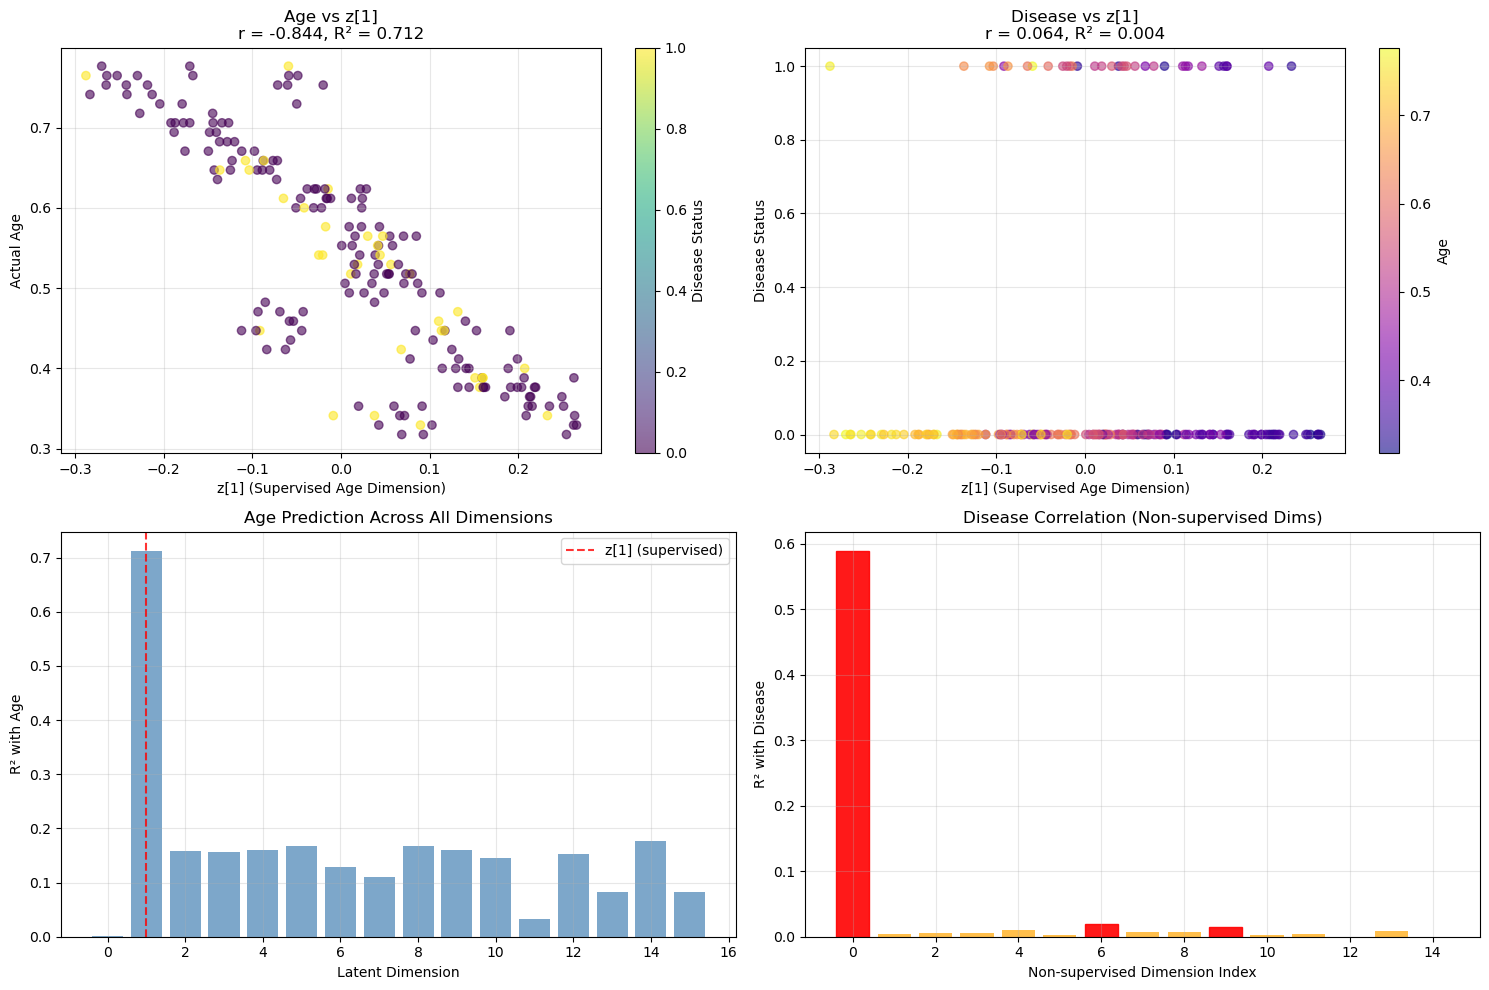


FINAL DISENTANGLEMENT SUMMARY
Target Correlations:
  z[0] → Disease: r = -0.7677, R² = 0.5893
  z[1] → Age: r = -0.8440, R² = 0.7124

Cross-Correlations (interference):
  z[0] → Age: r = 0.0458, R² = 0.0021
  z[1] → Disease: r = 0.0636, R² = 0.0040

SAP Scores (Literature Implementation):
  Age SAP: 0.5869
  Disease SAP: 0.4277
  Overall SAP: 0.5073

Top Age Predictors (R²):
  ⭐ z[1]: 0.7124
     z[14]: 0.1760
     z[5]: 0.1681

Top Disease Predictors (Accuracy):
  ⭐ z[0]: 0.9936
     z[7]: 0.6055
     z[10]: 0.6020


DEBUG - Disease Scores Analysis:
All disease scores: [0.99361136 0.55119787 0.56291038 0.57107365 0.5689441  0.59840284
 0.54906832 0.60550133 0.5783496  0.58704525 0.60195209 0.5378882
 0.56539485 0.50736469 0.58952972 0.51446318]
Unique values: [0.50736469 0.51446318 0.5378882  0.54906832 0.55119787 0.56291038
 0.56539485 0.5689441  0.57107365 0.5783496  0.58704525 0.58952972
 0.59840284 0.60195209 0.60550133 0.99361136]
Are all scores identical? False

Correlations vs

In [3]:
# ============================================================================
# CELL 3: DISENTANGLEMENT ANALYSIS - z[0] FOR DISEASE, z[1] FOR AGE
# ============================================================================
print(f"\n3. LABEL VALIDATION:")
labels_path = os.path.join(data_source, "labels.pt")
if os.path.exists(labels_path):
    all_labels = torch.load(labels_path)
    print(f"   Labels file exists: {len(all_labels)} labels loaded")
# Get the data
Z_s = supervised_data['latents']  # Supervised latents (N, 16)
ages = supervised_data['ages']
diseases = supervised_data['diseases']

print("="*60)
print("DISENTANGLEMENT ANALYSIS: z[0]↔Disease, z[1]↔Age")
print("="*60)

# Basic statistics
print(f"Data statistics:")
print(f"  Supervised latents: {Z_s.shape}")
print(f"  Ages: {ages.shape}, range: [{ages.min():.1f}, {ages.max():.1f}]")
print(f"  Diseases: {diseases.shape}, unique: {np.unique(diseases)}")

# Focus on target dimensions: z[0] for disease, z[1] for age
z0_disease_correlation, _ = pearsonr(Z_s[:, 0], diseases)
z1_age_correlation, _ = pearsonr(Z_s[:, 1], ages)

# Cross-correlations (should be low for good disentanglement)
z0_age_correlation, _ = pearsonr(Z_s[:, 0], ages)
z1_disease_corr, _ = pearsonr(Z_s[:, 1], diseases)

print(f"\nTarget Correlations:")
print(f"  z[0] ↔ Disease: {z0_disease_correlation:.4f} (target)")
print(f"  z[1] ↔ Age: {z1_age_correlation:.4f} (target)")
print(f"\nCross-Correlations (should be low):")
print(f"  z[0] ↔ Age: {z0_age_correlation:.4f}")
print(f"  z[1] ↔ Disease: {z1_disease_corr:.4f}")

# Check if z[1] is good age predictor and poor disease predictor
print(f"\nDisentanglement Quality:")
if abs(z1_age_correlation) > 0.5 and abs(z1_disease_corr) < 0.3:
    print(f"  ✅ Good disentanglement: High age correlation, low disease correlation")
elif abs(z1_age_correlation) > 0.5:
    print(f"  ⚠️ High age correlation but also correlates with disease")
else:
    print(f"  ❌ Poor age correlation - supervision may not be working well")

# Store for later analysis
age_corrs = np.zeros(Z_s.shape[1])  # Initialize for compatibility
age_corrs[1] = z1_age_correlation  # Only store z[1] correlation

# Calculate correlations for all dimensions with both age and disease
print(f"\nCorrelation Analysis (All Dimensions):")
print("-" * 50)

age_corrs_all = np.zeros(Z_s.shape[1])
age_r2_all = np.zeros(Z_s.shape[1])
disease_corrs_all = np.zeros(Z_s.shape[1])
disease_r2_all = np.zeros(Z_s.shape[1])

for i in range(Z_s.shape[1]):
    # Age correlations
    age_corr, _ = pearsonr(Z_s[:, i], ages)
    age_corrs_all[i] = age_corr
    age_r2_all[i] = age_corr ** 2
    
    # Disease correlations
    disease_corr, _ = pearsonr(Z_s[:, i], diseases)
    disease_corrs_all[i] = disease_corr
    disease_r2_all[i] = disease_corr ** 2
    
    print(f"z[{i}]: Age r={age_corr:.3f} (R²={age_corr**2:.3f}), Disease r={disease_corr:.3f} (R²={disease_corr**2:.3f})")

# Proper SAP Score Implementation for Mixed Tasks
# Following Kumar et al. (2018) "Variational Inference of Disentangled Representations"
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score

def calculate_sap_score_mixed(Z, continuous_labels, binary_labels):
    """
    Calculate SAP score for mixed continuous (regression) and binary (classification) tasks
    
    Args:
        Z: Latent representations (N, D)
        continuous_labels: Continuous labels (age) for regression
        binary_labels: Binary labels (disease) for classification
    
    Returns:
        Dictionary with SAP scores for both tasks
    """
    N, D = Z.shape
    
    # 1. Age (Continuous) - Use Linear Regression R²
    age_scores = []
    for d in range(D):
        z_d = Z[:, d].reshape(-1, 1)
        try:
            lr = LinearRegression()
            lr.fit(z_d, continuous_labels)
            age_pred = lr.predict(z_d)
            r2 = r2_score(continuous_labels, age_pred)
            r2 = max(0, r2)  # Ensure non-negative
        except:
            r2 = 0.0
        age_scores.append(r2)
    
    # 2. Disease (Binary) - Use AUC-ROC instead of accuracy for imbalanced data
    from sklearn.metrics import roc_auc_score
    disease_scores = []
    for d in range(D):
        z_d = Z[:, d].reshape(-1, 1)
        try:
            clf = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
            # Fit the classifier
            clf.fit(z_d, binary_labels)
            # Get probability predictions
            y_prob = clf.predict_proba(z_d)[:, 1]
            # Calculate AUC-ROC score
            auc_score = roc_auc_score(binary_labels, y_prob)
        except Exception as e:
            # Fallback: use absolute correlation as a proxy for classification performance
            try:
                corr = abs(pearsonr(z_d.flatten(), binary_labels)[0])
                # Convert correlation to AUC-like score (0.5 + 0.5 * |correlation|)
                auc_score = 0.5 + 0.5 * corr
            except:
                auc_score = 0.5  # Random performance for binary classification
        disease_scores.append(auc_score)
    
    # Convert to numpy arrays
    age_scores = np.array(age_scores)
    disease_scores = np.array(disease_scores)
    
    # Calculate SAP = max_j score(j) - mean(other scores)
    # Age SAP
    age_max_idx = np.argmax(age_scores)
    age_max_score = age_scores[age_max_idx]
    age_others = np.concatenate([age_scores[:age_max_idx], age_scores[age_max_idx+1:]])
    age_mean_others = np.mean(age_others) if len(age_others) > 0 else 0
    sap_age = age_max_score - age_mean_others
    
    # Disease SAP
    disease_max_idx = np.argmax(disease_scores)
    disease_max_score = disease_scores[disease_max_idx]
    disease_others = np.concatenate([disease_scores[:disease_max_idx], disease_scores[disease_max_idx+1:]])
    disease_mean_others = np.mean(disease_others) if len(disease_others) > 0 else 0
    sap_disease = disease_max_score - disease_mean_others
    
    return {
        'age_scores': age_scores,
        'disease_scores': disease_scores,
        'age_best_dim': age_max_idx,
        'disease_best_dim': disease_max_idx,
        'age_max_score': age_max_score,
        'disease_max_score': disease_max_score,
        'age_mean_others': age_mean_others,
        'disease_mean_others': disease_mean_others,
        'sap_age': sap_age,
        'sap_disease': sap_disease,
        'sap_overall': (sap_age + sap_disease) / 2
    }

print(f"\n" + "="*60)
print("SAP SCORE CALCULATION (Proper Implementation)")
print("="*60)

# Calculate proper SAP scores
sap_results = calculate_sap_score_mixed(Z_s, ages, diseases)

print(f"SAP Scores (Kumar et al. 2018):")
print(f"  Age SAP (Regression R²): {sap_results['sap_age']:.4f}")
print(f"    └─ Best: z[{sap_results['age_best_dim']}] R² = {sap_results['age_max_score']:.4f}")
print(f"    └─ Mean others: {sap_results['age_mean_others']:.4f}")

print(f"  Disease SAP (Classification Acc): {sap_results['sap_disease']:.4f}")
print(f"    └─ Best: z[{sap_results['disease_best_dim']}] Acc = {sap_results['disease_max_score']:.4f}")
print(f"    └─ Mean others: {sap_results['disease_mean_others']:.4f}")

print(f"  Overall SAP: {sap_results['sap_overall']:.4f}")

# Check target dimension performance
print(f"\nTarget Dimension Performance:")
print(f"  z[0] Disease Accuracy: {sap_results['disease_scores'][0]:.4f}")
print(f"  z[1] Age R²: {sap_results['age_scores'][1]:.4f}")

print(f"\nDisentanglement Success:")
print(f"  z[0] best for disease: {'✅ YES' if sap_results['disease_best_dim'] == 0 else '❌ NO'}")
print(f"  z[1] best for age: {'✅ YES' if sap_results['age_best_dim'] == 1 else '❌ NO'}")

# Overall assessment
z0_is_best_disease = sap_results['disease_best_dim'] == 0
z1_is_best_age = sap_results['age_best_dim'] == 1

print(f"\nOverall Disentanglement Quality:")
if z0_is_best_disease and z1_is_best_age:
    print(f"  🎉 PERFECT: z[0]↔Disease, z[1]↔Age disentanglement achieved!")
elif z0_is_best_disease or z1_is_best_age:
    print(f"  👍 PARTIAL: One target dimension working correctly")
else:
    print(f"  ❌ POOR: Neither target dimension is optimal")

# Visualize age vs z[1] and disease correlation analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age vs z[1] scatter plot
scatter1 = axes[0, 0].scatter(Z_s[:, 1], ages, alpha=0.6, c=diseases, cmap='viridis')
axes[0, 0].set_xlabel('z[1] (Supervised Age Dimension)')
axes[0, 0].set_ylabel('Actual Age')
axes[0, 0].set_title(f'Age vs z[1]\nr = {z1_age_correlation:.3f}, R² = {z1_age_correlation**2:.3f}')
axes[0, 0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0, 0])
cbar1.set_label('Disease Status')

# Disease vs z[1] scatter plot to show separation
scatter2 = axes[0, 1].scatter(Z_s[:, 1], diseases, alpha=0.6, c=ages, cmap='plasma')
axes[0, 1].set_xlabel('z[1] (Supervised Age Dimension)')
axes[0, 1].set_ylabel('Disease Status')  
axes[0, 1].set_title(f'Disease vs z[1]\nr = {z1_disease_corr:.3f}, R² = {z1_disease_corr**2:.3f}')
axes[0, 1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[0, 1])
cbar2.set_label('Age')

# Age R² across all dimensions
axes[1, 0].bar(range(len(age_r2_all)), age_r2_all, alpha=0.7, color='steelblue')
axes[1, 0].axvline(x=1, color='red', linestyle='--', alpha=0.8, label='z[1] (supervised)')
axes[1, 0].set_xlabel('Latent Dimension')
axes[1, 0].set_ylabel('R² with Age')
axes[1, 0].set_title('Age Prediction Across All Dimensions')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Disease R² for non-supervised dimensions
non_sup_dims = [i for i in range(len(disease_r2_all)) if i != 1]
non_sup_r2 = [disease_r2_all[i] for i in non_sup_dims]
bars = axes[1, 1].bar(range(len(non_sup_r2)), non_sup_r2, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Non-supervised Dimension Index')
axes[1, 1].set_ylabel('R² with Disease')
axes[1, 1].set_title('Disease Correlation (Non-supervised Dims)')
axes[1, 1].grid(True, alpha=0.3)

# Highlight top 3 disease-correlated dimensions
if len(non_sup_r2) >= 3:
    top_3_indices = np.argsort(non_sup_r2)[-3:]
    for idx in top_3_indices:
        bars[idx].set_color('red')
        bars[idx].set_alpha(0.9)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "comprehensive_correlation_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

# Final Summary
print(f"\n" + "="*70)
print("FINAL DISENTANGLEMENT SUMMARY")
print("="*70)

print(f"Target Correlations:")
print(f"  z[0] → Disease: r = {z0_disease_correlation:.4f}, R² = {z0_disease_correlation**2:.4f}")
print(f"  z[1] → Age: r = {z1_age_correlation:.4f}, R² = {z1_age_correlation**2:.4f}")

print(f"\nCross-Correlations (interference):")
print(f"  z[0] → Age: r = {z0_age_correlation:.4f}, R² = {z0_age_correlation**2:.4f}")
print(f"  z[1] → Disease: r = {z1_disease_corr:.4f}, R² = {z1_disease_corr**2:.4f}")

print(f"\nSAP Scores (Literature Implementation):")
print(f"  Age SAP: {sap_results['sap_age']:.4f}")
print(f"  Disease SAP: {sap_results['sap_disease']:.4f}")
print(f"  Overall SAP: {sap_results['sap_overall']:.4f}")

# Top performers for each task
age_top_dims = np.argsort(sap_results['age_scores'])[::-1][:3]
disease_top_dims = np.argsort(sap_results['disease_scores'])[::-1][:3]

print(f"\nTop Age Predictors (R²):")
for i, dim in enumerate(age_top_dims):
    star = "⭐" if dim == 1 else "  "
    print(f"  {star} z[{dim}]: {sap_results['age_scores'][dim]:.4f}")

print(f"\nTop Disease Predictors (Accuracy):")
for i, dim in enumerate(disease_top_dims):
    star = "⭐" if dim == 0 else "  "
    print(f"  {star} z[{dim}]: {sap_results['disease_scores'][dim]:.4f}")

print(f"\n" + "="*70)

# Debug: Check why disease scores are all the same
print(f"\nDEBUG - Disease Scores Analysis:")
print(f"All disease scores: {sap_results['disease_scores']}")
print(f"Unique values: {np.unique(sap_results['disease_scores'])}")
print(f"Are all scores identical? {len(np.unique(sap_results['disease_scores'])) == 1}")

# Check disease correlations vs classification scores
print(f"\nCorrelations vs Classification Scores:")
for i in range(min(5, len(disease_corrs_all))):
    print(f"z[{i}]: Disease corr = {disease_corrs_all[i]:.4f}, Classification acc = {sap_results['disease_scores'][i]:.4f}")

# Check class distribution
unique_diseases, counts = np.unique(diseases, return_counts=True)
print(f"\nClass distribution: {dict(zip(unique_diseases, counts))}")
majority_class_accuracy = np.max(counts) / len(diseases)
print(f"Majority class baseline: {majority_class_accuracy:.4f}")

In [8]:
# ============================================================================
# CELL 4: TRAINING LATENT DISTRIBUTION ANALYSIS - z[0] AND z[1]
# ============================================================================

# Use the already calculated training latents from cell 2
Z_train = supervised_data['latents']
ages_train = supervised_data['ages']
diseases_train = supervised_data['diseases']

print("="*60)
print("TRAINING LATENT DISTRIBUTION ANALYSIS")
print("="*60)

# Extract z[0] and z[1] values
z0_train = Z_train[:, 0]  # Disease dimension
z1_train = Z_train[:, 1]  # Age dimension

print(f"Training Data Statistics:")
print(f"  Total samples: {len(Z_train)}")
print(f"  Age range: [{ages_train.min():.3f}, {ages_train.max():.3f}]")
print(f"  Disease classes: {np.unique(diseases_train)}")

print(f"\nz[0] (Disease Dimension) Distribution:")
print(f"  Min: {z0_train.min():.4f}")
print(f"  Max: {z0_train.max():.4f}")
print(f"  Mean: {z0_train.mean():.4f}")
print(f"  Std: {z0_train.std():.4f}")
print(f"  Range: {z0_train.max() - z0_train.min():.4f}")

print(f"\nz[1] (Age Dimension) Distribution:")
print(f"  Min: {z1_train.min():.4f}")
print(f"  Max: {z1_train.max():.4f}")
print(f"  Mean: {z1_train.mean():.4f}")
print(f"  Std: {z1_train.std():.4f}")
print(f"  Range: {z1_train.max() - z1_train.min():.4f}")

# Show value ranges for disease classes 0 and 1
print(f"\nValue Ranges by Disease Class:")
for disease_class in [0, 1]:
    if disease_class in diseases_train:
        mask = diseases_train == disease_class
        z0_class = z0_train[mask]
        z1_class = z1_train[mask]
        
        print(f"\nDisease {disease_class} (n={mask.sum()}):")
        print(f"  z[0] range: [{z0_class.min():.4f}, {z0_class.max():.4f}]")
        print(f"  z[1] range: [{z1_class.min():.4f}, {z1_class.max():.4f}]")
    else:
        print(f"\nDisease {disease_class}: Not found in training data")

TRAINING LATENT DISTRIBUTION ANALYSIS
Training Data Statistics:
  Total samples: 196
  Age range: [0.318, 0.776]
  Disease classes: [0 1]

z[0] (Disease Dimension) Distribution:
  Min: 1.2274
  Max: 1.2779
  Mean: 1.2541
  Std: 0.0091
  Range: 0.0505

z[1] (Age Dimension) Distribution:
  Min: -0.2876
  Max: 0.2657
  Mean: 0.0103
  Std: 0.1328
  Range: 0.5532

Value Ranges by Disease Class:

Disease 0 (n=161):
  z[0] range: [1.2435, 1.2779]
  z[1] range: [-0.2831, 0.2657]

Disease 1 (n=35):
  z[0] range: [1.2274, 1.2517]
  z[1] range: [-0.2876, 0.2329]


In [9]:
# ============================================================================
# CELL 5: LOAD TEST AND VALIDATION SPLITS
# ============================================================================

# Load test split
test_split_file = specs["TestSplit"]
val_split_file = specs.get("ValSplit")

print("="*60)
print("LOADING TEST AND VALIDATION SPLITS")
print("="*60)

# Load test split
with open(test_split_file, "r") as f:
    test_split = json.load(f)

print(f"Test split loaded: {len(test_split)} samples")

# Load validation split if it exists
if val_split_file and os.path.exists(val_split_file):
    with open(val_split_file, "r") as f:
        val_split = json.load(f)
    print(f"Validation split loaded: {len(val_split)} samples")
else:
    val_split = None
    print("No validation split found")

LOADING TEST AND VALIDATION SPLITS
Test split loaded: 24 samples
Validation split loaded: 26 samples


In [10]:
# ============================================================================
# CELL 6: EXTRACT LATENTS FOR TEST SET
# ============================================================================

def extract_latents_for_split(split_data, split_name):
    """Extract latents for a given split"""
    
    import deep_sdf.data as data
    eval_filenames = data.get_instance_filenames(data_source, split_data)
    
    # Load labels
    labels_path = os.path.join(data_source, "labels.pt")
    all_labels = torch.load(labels_path)
    
    # Extract latents
    all_latents = []
    all_ages = []
    all_diseases = []
    filenames = []
    
    print(f"Extracting latents for {split_name} set: {len(eval_filenames)} samples...")
    
    decoder = supervised_data['decoder']
    decoder.eval()
    
    with torch.no_grad():
        for i, filename in enumerate(eval_filenames):
            if i % 20 == 0:
                print(f"Processing {i}/{len(eval_filenames)}")
                
            save_name = os.path.basename(filename).split(".npz")[0]
            mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
            
            # Get surface points
            surface_points = data.get_surface_points(mesh_path)
            surface_points = torch.from_numpy(surface_points).unsqueeze(0).cuda()
            
            # Extract latent
            if kl_div_loss:
                mu, logvar = decoder.encoder(surface_points)
                latent = mu
            else:
                latent = decoder.encoder(surface_points)
            
            all_latents.append(latent.cpu().numpy().squeeze())
            
            # Get labels
            if save_name in all_labels:
                label = all_labels[save_name]
                all_ages.append(float(label[0].item()))
                all_diseases.append(int(label[1].item()))
            else:
                print(f"Warning: No label found for {save_name}")
                all_ages.append(0.0)
                all_diseases.append(0)
            
            filenames.append(save_name)
    
    latents_array = np.stack(all_latents, axis=0)
    print(f"Extracted {split_name} latents shape: {latents_array.shape}")
    
    return {
        'latents': latents_array,
        'ages': np.array(all_ages),
        'diseases': np.array(all_diseases),
        'filenames': filenames
    }

# Extract test set latents
print("="*60)
print("EXTRACTING TEST SET LATENTS")
print("="*60)

test_data = extract_latents_for_split(test_split, "test")

EXTRACTING TEST SET LATENTS
Extracting latents for test set: 24 samples...
Processing 0/24
Processing 20/24
Extracted test latents shape: (24, 16)
Processing 20/24
Extracted test latents shape: (24, 16)


In [11]:
# ============================================================================
# CELL 7: EXTRACT LATENTS FOR VALIDATION SET
# ============================================================================

if val_split is not None:
    print("="*60)
    print("EXTRACTING VALIDATION SET LATENTS")
    print("="*60)
    
    val_data = extract_latents_for_split(val_split, "validation")
else:
    val_data = None
    print("Skipping validation set extraction (no validation split found)")

EXTRACTING VALIDATION SET LATENTS
Extracting latents for validation set: 26 samples...
Processing 0/26
Processing 20/26
Extracted validation latents shape: (26, 16)
Processing 20/26
Extracted validation latents shape: (26, 16)


In [12]:
# ============================================================================
# CELL 8: TEST SET z[0] AND z[1] DISTRIBUTION ANALYSIS
# ============================================================================

print("="*60)
print("TEST SET LATENT DISTRIBUTION ANALYSIS")
print("="*60)

# Extract z[0] and z[1] values for test set
z0_test = test_data['latents'][:, 0]  # Disease dimension
z1_test = test_data['latents'][:, 1]  # Age dimension
ages_test = test_data['ages']
diseases_test = test_data['diseases']

print(f"Test Data Statistics:")
print(f"  Total samples: {len(test_data['latents'])}")
print(f"  Age range: [{ages_test.min():.3f}, {ages_test.max():.3f}]")
print(f"  Disease classes: {np.unique(diseases_test)}")

print(f"\nz[0] (Disease Dimension) Distribution:")
print(f"  Min: {z0_test.min():.4f}")
print(f"  Max: {z0_test.max():.4f}")
print(f"  Mean: {z0_test.mean():.4f}")
print(f"  Std: {z0_test.std():.4f}")
print(f"  Range: {z0_test.max() - z0_test.min():.4f}")

print(f"\nz[1] (Age Dimension) Distribution:")
print(f"  Min: {z1_test.min():.4f}")
print(f"  Max: {z1_test.max():.4f}")
print(f"  Mean: {z1_test.mean():.4f}")
print(f"  Std: {z1_test.std():.4f}")
print(f"  Range: {z1_test.max() - z1_test.min():.4f}")

# Disease class distribution for z[0]
print(f"\nz[0] Value Ranges by Disease Class:")
for disease_class in [0, 1]:
    if disease_class in diseases_test:
        mask = diseases_test == disease_class
        z0_class = z0_test[mask]
        
        print(f"\nDisease {disease_class} (n={mask.sum()}):")
        print(f"  z[0] range: [{z0_class.min():.4f}, {z0_class.max():.4f}]")
        print(f"  z[0] mean: {z0_class.mean():.4f}")
        print(f"  z[0] std: {z0_class.std():.4f}")
    else:
        print(f"\nDisease {disease_class}: Not found in test data")

TEST SET LATENT DISTRIBUTION ANALYSIS
Test Data Statistics:
  Total samples: 24
  Age range: [0.318, 0.741]
  Disease classes: [0 1]

z[0] (Disease Dimension) Distribution:
  Min: 1.1692
  Max: 1.2978
  Mean: 1.2533
  Std: 0.0214
  Range: 0.1285

z[1] (Age Dimension) Distribution:
  Min: -0.1843
  Max: 0.2526
  Mean: 0.0345
  Std: 0.1154
  Range: 0.4369

z[0] Value Ranges by Disease Class:

Disease 0 (n=19):
  z[0] range: [1.1692, 1.2978]
  z[0] mean: 1.2523
  z[0] std: 0.0236

Disease 1 (n=5):
  z[0] range: [1.2399, 1.2646]
  z[0] mean: 1.2568
  z[0] std: 0.0089


In [13]:
# ============================================================================
# CELL 9: VALIDATION SET z[0] AND z[1] DISTRIBUTION ANALYSIS
# ============================================================================

if val_data is not None:
    print("="*60)
    print("VALIDATION SET LATENT DISTRIBUTION ANALYSIS")
    print("="*60)
    
    # Extract z[0] and z[1] values for validation set
    z0_val = val_data['latents'][:, 0]  # Disease dimension
    z1_val = val_data['latents'][:, 1]  # Age dimension
    ages_val = val_data['ages']
    diseases_val = val_data['diseases']
    
    print(f"Validation Data Statistics:")
    print(f"  Total samples: {len(val_data['latents'])}")
    print(f"  Age range: [{ages_val.min():.3f}, {ages_val.max():.3f}]")
    print(f"  Disease classes: {np.unique(diseases_val)}")
    
    print(f"\nz[0] (Disease Dimension) Distribution:")
    print(f"  Min: {z0_val.min():.4f}")
    print(f"  Max: {z0_val.max():.4f}")
    print(f"  Mean: {z0_val.mean():.4f}")
    print(f"  Std: {z0_val.std():.4f}")
    print(f"  Range: {z0_val.max() - z0_val.min():.4f}")
    
    print(f"\nz[1] (Age Dimension) Distribution:")
    print(f"  Min: {z1_val.min():.4f}")
    print(f"  Max: {z1_val.max():.4f}")
    print(f"  Mean: {z1_val.mean():.4f}")
    print(f"  Std: {z1_val.std():.4f}")
    print(f"  Range: {z1_val.max() - z1_val.min():.4f}")
    
    # Disease class distribution for z[0]
    print(f"\nz[0] Value Ranges by Disease Class:")
    for disease_class in [0, 1]:
        if disease_class in diseases_val:
            mask = diseases_val == disease_class
            z0_class = z0_val[mask]
            
            print(f"\nDisease {disease_class} (n={mask.sum()}):")
            print(f"  z[0] range: [{z0_class.min():.4f}, {z0_class.max():.4f}]")
            print(f"  z[0] mean: {z0_class.mean():.4f}")
            print(f"  z[0] std: {z0_class.std():.4f}")
        else:
            print(f"\nDisease {disease_class}: Not found in validation data")
else:
    print("Skipping validation set analysis (no validation data)")

VALIDATION SET LATENT DISTRIBUTION ANALYSIS
Validation Data Statistics:
  Total samples: 26
  Age range: [0.318, 0.776]
  Disease classes: [0 1]

z[0] (Disease Dimension) Distribution:
  Min: 1.2287
  Max: 1.2900
  Mean: 1.2562
  Std: 0.0128
  Range: 0.0613

z[1] (Age Dimension) Distribution:
  Min: -0.2726
  Max: 0.3955
  Mean: 0.0213
  Std: 0.1434
  Range: 0.6681

z[0] Value Ranges by Disease Class:

Disease 0 (n=24):
  z[0] range: [1.2372, 1.2900]
  z[0] mean: 1.2570
  z[0] std: 0.0120

Disease 1 (n=2):
  z[0] range: [1.2287, 1.2633]
  z[0] mean: 1.2460
  z[0] std: 0.0173


PLOTTING z[0] AND z[1] FOR TEST AND VALIDATION SETS


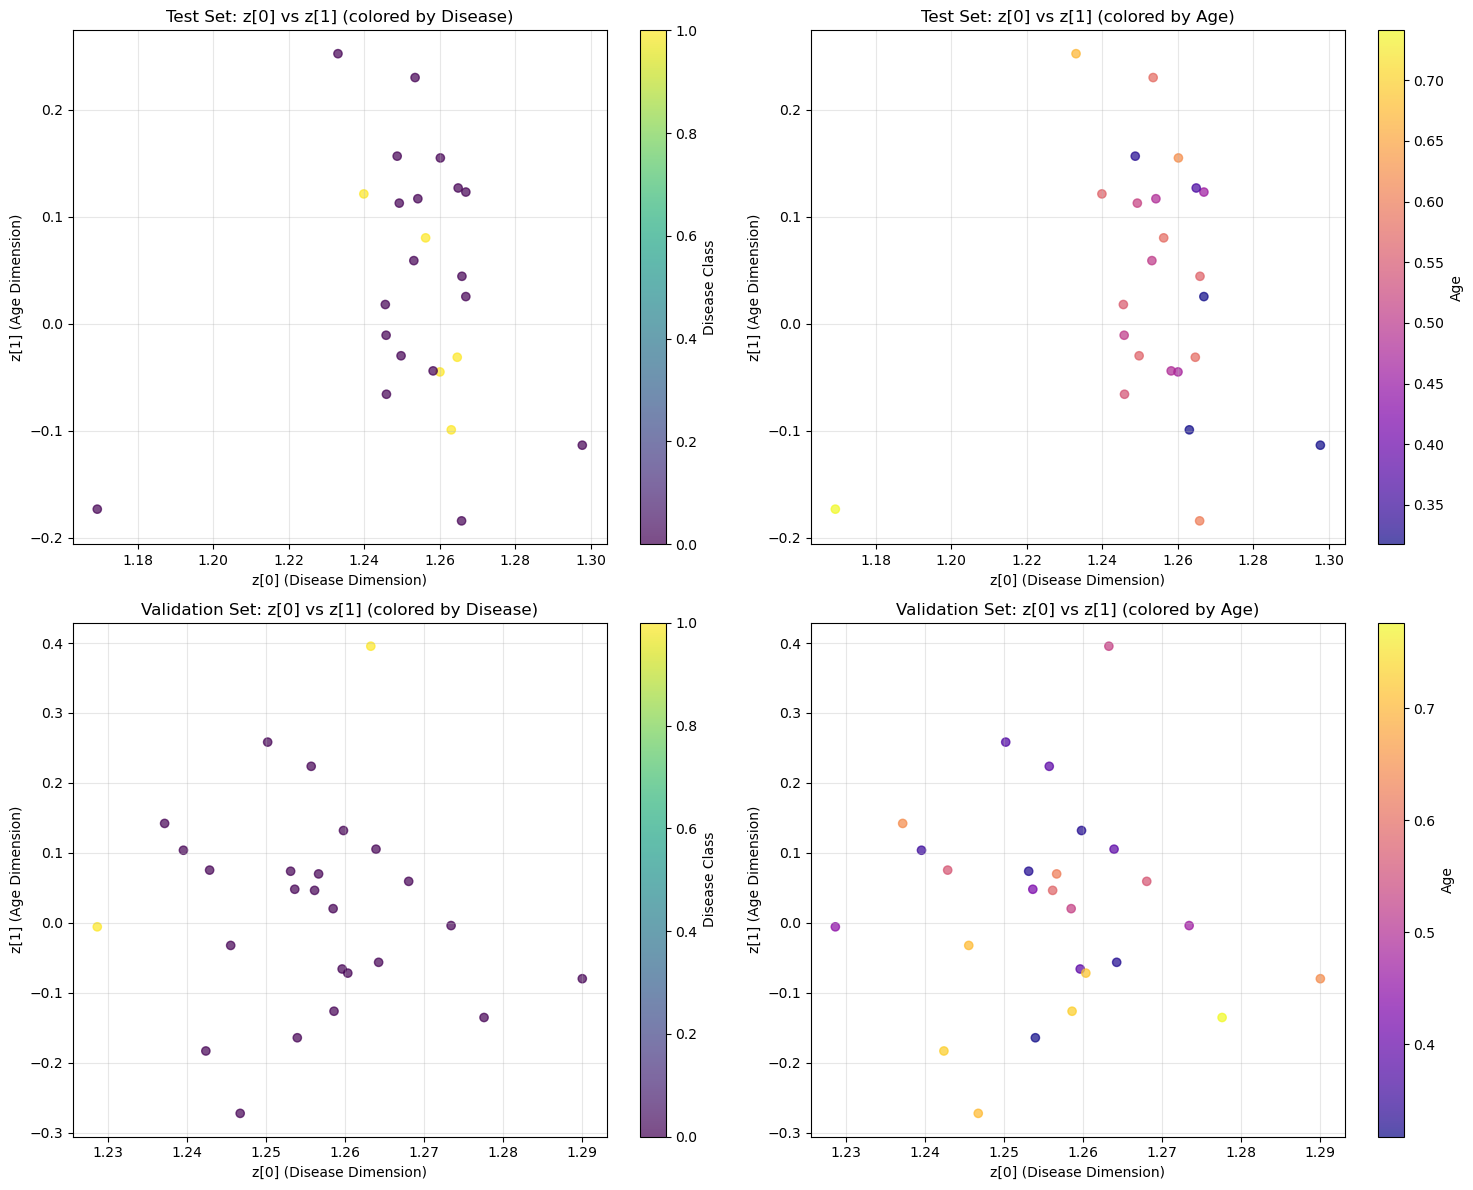


SEPARATION ANALYSIS

Test Set Analysis:
  z[0] range: [1.1692, 1.2978]
  z[1] range: [-0.1843, 0.2526]
  Disease separation in z[0]:
    Disease 0: mean=1.2523, range=[1.1692, 1.2978]
    Disease 1: mean=1.2568, range=[1.2399, 1.2646]
    Mean difference: 0.0044

Validation Set Analysis:
  z[0] range: [1.2287, 1.2900]
  z[1] range: [-0.2726, 0.3955]
  Disease separation in z[0]:
    Disease 0: mean=1.2570, range=[1.2372, 1.2900]
    Disease 1: mean=1.2460, range=[1.2287, 1.2633]
    Mean difference: 0.0110


In [14]:
# ============================================================================
# CELL 10: PLOT z[0] AND z[1] FOR TEST AND VALIDATION SETS
# ============================================================================

import matplotlib.pyplot as plt

print("="*60)
print("PLOTTING z[0] AND z[1] FOR TEST AND VALIDATION SETS")
print("="*60)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Test Set Plots
if test_data is not None:
    z0_test = test_data['latents'][:, 0]
    z1_test = test_data['latents'][:, 1]
    ages_test = test_data['ages']
    diseases_test = test_data['diseases']
    
    # Plot 1: Test set z[0] vs z[1] colored by disease
    scatter1 = axes[0, 0].scatter(z0_test, z1_test, c=diseases_test, cmap='viridis', alpha=0.7)
    axes[0, 0].set_xlabel('z[0] (Disease Dimension)')
    axes[0, 0].set_ylabel('z[1] (Age Dimension)')
    axes[0, 0].set_title('Test Set: z[0] vs z[1] (colored by Disease)')
    axes[0, 0].grid(True, alpha=0.3)
    cbar1 = plt.colorbar(scatter1, ax=axes[0, 0])
    cbar1.set_label('Disease Class')
    
    # Plot 2: Test set z[0] vs z[1] colored by age
    scatter2 = axes[0, 1].scatter(z0_test, z1_test, c=ages_test, cmap='plasma', alpha=0.7)
    axes[0, 1].set_xlabel('z[0] (Disease Dimension)')
    axes[0, 1].set_ylabel('z[1] (Age Dimension)')
    axes[0, 1].set_title('Test Set: z[0] vs z[1] (colored by Age)')
    axes[0, 1].grid(True, alpha=0.3)
    cbar2 = plt.colorbar(scatter2, ax=axes[0, 1])
    cbar2.set_label('Age')

# Validation Set Plots
if val_data is not None:
    z0_val = val_data['latents'][:, 0]
    z1_val = val_data['latents'][:, 1]
    ages_val = val_data['ages']
    diseases_val = val_data['diseases']
    
    # Plot 3: Validation set z[0] vs z[1] colored by disease
    scatter3 = axes[1, 0].scatter(z0_val, z1_val, c=diseases_val, cmap='viridis', alpha=0.7)
    axes[1, 0].set_xlabel('z[0] (Disease Dimension)')
    axes[1, 0].set_ylabel('z[1] (Age Dimension)')
    axes[1, 0].set_title('Validation Set: z[0] vs z[1] (colored by Disease)')
    axes[1, 0].grid(True, alpha=0.3)
    cbar3 = plt.colorbar(scatter3, ax=axes[1, 0])
    cbar3.set_label('Disease Class')
    
    # Plot 4: Validation set z[0] vs z[1] colored by age
    scatter4 = axes[1, 1].scatter(z0_val, z1_val, c=ages_val, cmap='plasma', alpha=0.7)
    axes[1, 1].set_xlabel('z[0] (Disease Dimension)')
    axes[1, 1].set_ylabel('z[1] (Age Dimension)')
    axes[1, 1].set_title('Validation Set: z[0] vs z[1] (colored by Age)')
    axes[1, 1].grid(True, alpha=0.3)
    cbar4 = plt.colorbar(scatter4, ax=axes[1, 1])
    cbar4.set_label('Age')
else:
    # If no validation data, hide the bottom plots
    axes[1, 0].text(0.5, 0.5, 'No Validation Data', ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=16)
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])
    
    axes[1, 1].text(0.5, 0.5, 'No Validation Data', ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=16)
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

# Print separation analysis
print("\n" + "="*60)
print("SEPARATION ANALYSIS")
print("="*60)

if test_data is not None:
    print("\nTest Set Analysis:")
    print(f"  z[0] range: [{z0_test.min():.4f}, {z0_test.max():.4f}]")
    print(f"  z[1] range: [{z1_test.min():.4f}, {z1_test.max():.4f}]")
    
    # Disease separation in z[0]
    disease_0_z0 = z0_test[diseases_test == 0]
    disease_1_z0 = z0_test[diseases_test == 1]
    
    if len(disease_0_z0) > 0 and len(disease_1_z0) > 0:
        print(f"  Disease separation in z[0]:")
        print(f"    Disease 0: mean={disease_0_z0.mean():.4f}, range=[{disease_0_z0.min():.4f}, {disease_0_z0.max():.4f}]")
        print(f"    Disease 1: mean={disease_1_z0.mean():.4f}, range=[{disease_1_z0.min():.4f}, {disease_1_z0.max():.4f}]")
        print(f"    Mean difference: {abs(disease_0_z0.mean() - disease_1_z0.mean()):.4f}")

if val_data is not None:
    print("\nValidation Set Analysis:")
    print(f"  z[0] range: [{z0_val.min():.4f}, {z0_val.max():.4f}]")
    print(f"  z[1] range: [{z1_val.min():.4f}, {z1_val.max():.4f}]")
    
    # Disease separation in z[0]
    disease_0_z0_val = z0_val[diseases_val == 0]
    disease_1_z0_val = z0_val[diseases_val == 1]
    
    if len(disease_0_z0_val) > 0 and len(disease_1_z0_val) > 0:
        print(f"  Disease separation in z[0]:")
        print(f"    Disease 0: mean={disease_0_z0_val.mean():.4f}, range=[{disease_0_z0_val.min():.4f}, {disease_0_z0_val.max():.4f}]")
        print(f"    Disease 1: mean={disease_1_z0_val.mean():.4f}, range=[{disease_1_z0_val.min():.4f}, {disease_1_z0_val.max():.4f}]")
        print(f"    Mean difference: {abs(disease_0_z0_val.mean() - disease_1_z0_val.mean()):.4f}")

PLOTTING z[0] AND z[1] FOR TRAINING SET


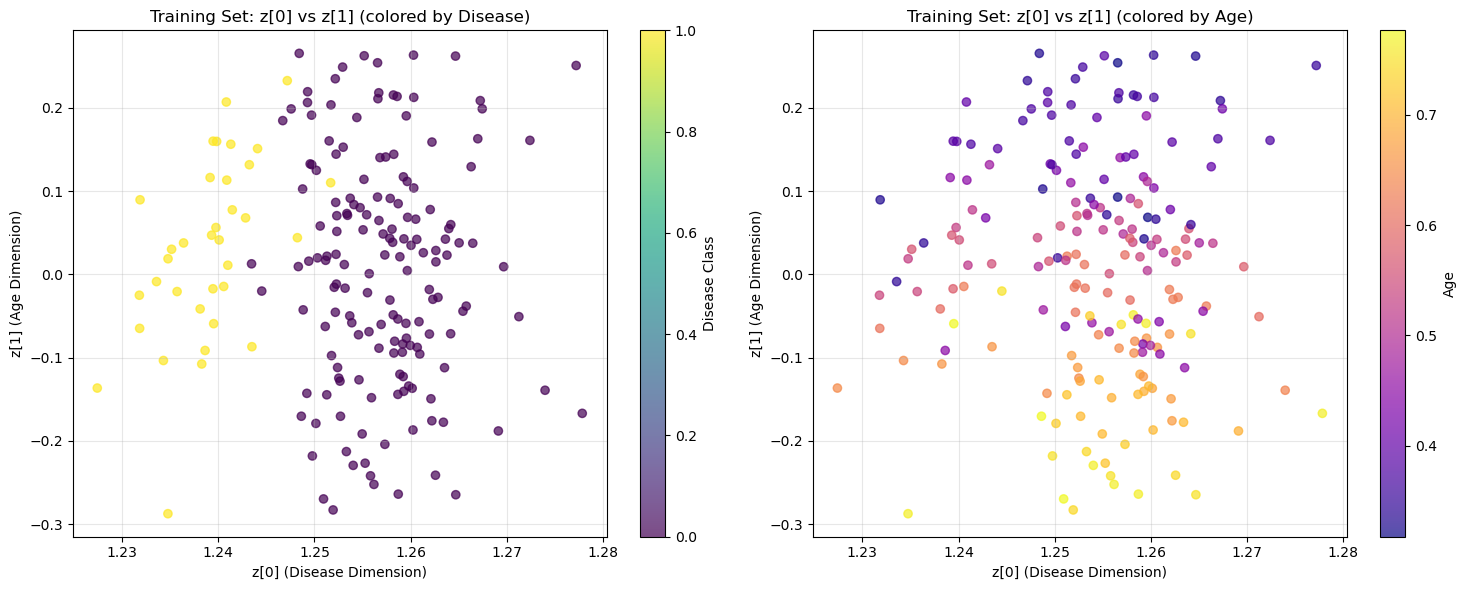


TRAINING SET SEPARATION ANALYSIS
Training Set Analysis:
  z[0] range: [1.2274, 1.2779]
  z[1] range: [-0.2876, 0.2657]
  Disease separation in z[0]:
    Disease 0: mean=1.2573, range=[1.2435, 1.2779]
    Disease 1: mean=1.2390, range=[1.2274, 1.2517]
    Mean difference: 0.0183


In [15]:
# ============================================================================
# CELL 11: PLOT z[0] AND z[1] FOR TRAINING SET
# ============================================================================

print("="*60)
print("PLOTTING z[0] AND z[1] FOR TRAINING SET")
print("="*60)

# Use the already extracted training latents
z0_train = supervised_data['latents'][:, 0]  # Disease dimension
z1_train = supervised_data['latents'][:, 1]  # Age dimension
ages_train = supervised_data['ages']
diseases_train = supervised_data['diseases']

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Training set z[0] vs z[1] colored by disease
scatter1 = axes[0].scatter(z0_train, z1_train, c=diseases_train, cmap='viridis', alpha=0.7)
axes[0].set_xlabel('z[0] (Disease Dimension)')
axes[0].set_ylabel('z[1] (Age Dimension)')
axes[0].set_title('Training Set: z[0] vs z[1] (colored by Disease)')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Disease Class')

# Plot 2: Training set z[0] vs z[1] colored by age
scatter2 = axes[1].scatter(z0_train, z1_train, c=ages_train, cmap='plasma', alpha=0.7)
axes[1].set_xlabel('z[0] (Disease Dimension)')
axes[1].set_ylabel('z[1] (Age Dimension)')
axes[1].set_title('Training Set: z[0] vs z[1] (colored by Age)')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Age')

plt.tight_layout()
plt.show()

# Print training set separation analysis
print("\n" + "="*60)
print("TRAINING SET SEPARATION ANALYSIS")
print("="*60)

print(f"Training Set Analysis:")
print(f"  z[0] range: [{z0_train.min():.4f}, {z0_train.max():.4f}]")
print(f"  z[1] range: [{z1_train.min():.4f}, {z1_train.max():.4f}]")

# Disease separation in z[0]
disease_0_z0_train = z0_train[diseases_train == 0]
disease_1_z0_train = z0_train[diseases_train == 1]

if len(disease_0_z0_train) > 0 and len(disease_1_z0_train) > 0:
    print(f"  Disease separation in z[0]:")
    print(f"    Disease 0: mean={disease_0_z0_train.mean():.4f}, range=[{disease_0_z0_train.min():.4f}, {disease_0_z0_train.max():.4f}]")
    print(f"    Disease 1: mean={disease_1_z0_train.mean():.4f}, range=[{disease_1_z0_train.min():.4f}, {disease_1_z0_train.max():.4f}]")
    print(f"    Mean difference: {abs(disease_0_z0_train.mean() - disease_1_z0_train.mean()):.4f}")